In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as trn

import clip
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from data_loading import load_sun_data
from dataloaders import create_sun_dataloader
from cav_utils import (calculate_filtered_cav, calculate_centroid_cav,
                       get_cosine_similarity, get_dot_product_similarity, 
                       get_concept_distribution_stats, is_obs_in_concept)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Używane urządzenie: {DEVICE}")

Używane urządzenie: cuda


In [2]:
model_file = 'models/resnet18_places365.pth'
conv_model = models.resnet18(num_classes=365)
checkpoint = torch.load(model_file, map_location=lambda storage, loc: storage)
state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model.load_state_dict(state_dict)
conv_model.fc = nn.Identity() 
conv_model = conv_model.to(DEVICE).eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)),
    trn.CenterCrop(224),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print(f'Modele załadowane. Wymiar embeddingu CLIP: {clip_model.visual.output_dim}')

Modele załadowane. Wymiar embeddingu CLIP: 512


In [3]:
df_sun, attributes_list, attr_cols = load_sun_data(base_path='data/SUN/SUNAttributeDB', threshold=0.5)

print(f'Images read: {len(df_sun)}')
print(f'Number of attributes: {len(attr_cols)}')

df_sun.head(3)

Images read: 14340
Number of attributes: 102


,image_id,file_path,class_id,sailing/ boating,driving,biking,transporting things or people,sunbathing,vacationing/ touring,hiking,...,far-away horizon,no horizon,rugged scene,mostly vertical components,mostly horizontal components,symmetrical,cluttered space,scary,soothing,stressful
0,1,a/abbey/sun_aakbdcgfpksytcwj.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,a/abbey/sun_aaoktempcmudsvna.jpg,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,a/abbey/sun_abegcweqnetpdlrh.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
dataloader_resnet = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=centre_crop,
    attr_cols=attr_cols, batch_size=32, num_workers=4
)

dataloader_clip = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=clip_preprocess,
    attr_cols=attr_cols, batch_size=64, num_workers=4)

In [5]:
def extract_clip_features(dataloader, model):
    """Przepuszcza obrazy przez CLIP i zwraca znormalizowane wektory."""
    all_features = []
    all_labels = []
    all_paths = []
    
    #model.eval()
    with torch.no_grad():
        for imgs, labels, paths in tqdm(dataloader, desc="Ekstrakcja cech CLIP"):
            features = model.encode_image(imgs.to(DEVICE))
            features = features / features.norm(dim=-1, keepdim=True)
            
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())
            all_paths.extend(paths)
            
    return np.vstack(all_features), np.vstack(all_labels), all_paths


features_clip, labels_clip, paths_clip = extract_clip_features(dataloader_clip, clip_model)
df_labels = pd.DataFrame(labels_clip, columns=attr_cols)

Ekstrakcja cech CLIP:   0%|          | 0/225 [00:00<?, ?it/s]/home/JanTar/miniconda3/envs/automl/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv2d(input, weight, bias, self.stride,
Ekstrakcja cech CLIP: 100%|██████████| 225/225 [02:41<00:00,  1.40it/s]


In [6]:
def extract_resnet_features(dataloader, model):
    all_features = []
    
    with torch.no_grad():
        for imgs, labels, paths in tqdm(dataloader, desc="Downloading ResNet features"):
            features = model(imgs.to(DEVICE))
            features = features / features.norm(dim=-1, keepdim=True)
            all_features.append(features.cpu().numpy())
            
    return np.vstack(all_features)

print("Downloading ResNet features...")
features_resnet = extract_resnet_features(dataloader_resnet, conv_model)

print(f"Shape of CLIP features: {features_clip.shape}")
print(f"Shape of ResNet features: {features_resnet.shape}")

Shape of CLIP features: (14340, 512)
Shape of ResNet features: (14340, 512)


In [7]:
indices = np.arange(len(df_sun))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

df_train = df_labels.iloc[train_idx].reset_index(drop=True)
df_test  = df_labels.iloc[test_idx].reset_index(drop=True)

X_train_clip = features_clip[train_idx]
X_test_clip  = features_clip[test_idx]

X_train_resnet = features_resnet[train_idx]
X_test_resnet  = features_resnet[test_idx]

print(f"Training set: {len(train_idx)} samples")
print(f"Test set: {len(test_idx)} samples")

def calculate_standard_cav(features_matrix, pos_indices, neg_indices):
    mean_concept = np.mean(features_matrix[pos_indices], axis=0)
    mean_background = np.mean(features_matrix[neg_indices], axis=0)
    
    cav = mean_concept - mean_background
    norm = np.linalg.norm(cav)
    if norm > 1e-8:
        return cav / norm
    raise ValueError('Norma CAV jest bliska zeru.')

Training set: 11472 samples
Test set: 2868 samples


In [8]:
hierarchies_to_test = [
    # empirical
    ('research', 'enclosed area'),
    ('camping', 'open area'),
    ('medical activity', 'enclosed area'),
    ('gaming', 'enclosed area'),
    ('sand', 'natural light'),
    ('carpet', 'enclosed area'),

    # sematical
    ('ocean', 'open area'),
    ('conducting business', 'working'),
    ('pavement', 'asphalt'),
    ('climbing', 'rock/stone'), 
    ('rusty', 'aged/ worn'),  
    ('ice', 'cold')
]

def evaluate_cav_methods(X_train, X_test, df_train, df_test, pairs, model_name):
    print("\n" + "="*80)
    print(f"EWALUATION FOR MODEL: {model_name.upper()}")
    print("="*80)
    print(f"{'SUBCONCEPT':<18} | {'PARENT':<15} | {'AUC STD CAV':<15} | {'AUC FILTERED CAV':<16}")
    print("-" * 80)
    
    results = []
    
    for child, parent in pairs:
        # --- TRENING ---
        # 1. Indeksy dla standardowego CAV (cały zbiór treningowy)
        child_pos_train = df_train.index[df_train[child] == 1.0].to_numpy()
        child_neg_train = df_train.index[df_train[child] == 0.0].to_numpy()
        
        # 2. Indeksy dla Filtered CAV (pojęcie rodzica musi istnieć)
        parent_pos_train = df_train.index[df_train[parent] == 1.0].to_numpy()
        
        # Zabezpieczenie przed brakiem danych
        if len(child_pos_train) == 0 or len(parent_pos_train) == 0:
            continue
            
        try:
            # Trenujemy oba wektory
            cav_std = calculate_standard_cav(X_train, child_pos_train, child_neg_train)
            cav_filtered = calculate_filtered_cav(X_train, child_pos_train, child_neg_train, parent_pos_train)
        except ValueError:
            continue # Pomijamy jeśli brakuje danych w przecięciu (Filtered)
            
            
        # --- TESTOWANIE (TWARDE NEGATYWY) ---
        # Filtrujemy zbiór testowy do obrazów, gdzie WYSTĘPUJE pojęcie rodzica
        hard_mask_test = df_test[parent] == 1.0
        
        y_true_hard = df_test[child][hard_mask_test].values
        X_hard = X_test[hard_mask_test]
        
        # Sprawdzamy czy mamy pozytywy i negatywy do wyliczenia AUC
        if len(np.unique(y_true_hard)) > 1:
            # Przewidywania (podobieństwo kosinusowe)
            scores_std = cosine_similarity(X_hard, cav_std.reshape(1, -1)).flatten()
            scores_filtered = cosine_similarity(X_hard, cav_filtered.reshape(1, -1)).flatten()
            
            auc_std = roc_auc_score(y_true_hard, scores_std)
            auc_filtered = roc_auc_score(y_true_hard, scores_filtered)
            diff = auc_filtered - auc_std


            results.append({
                'child': child, 'parent': parent, 
                'auc_std': auc_std, 
                'auc_filtered': auc_filtered,
                'auc_diff': diff
            })
            
            znak = "+++" if auc_filtered > auc_std else "---"
            print(f"{child:<18} | {parent:<15} | {auc_std:<15.4f} | {auc_filtered:<15.4f} {znak} | Diff: {diff:+.4f}")
        else:
            print(f"{child:<18} | {parent:<15} | {'---':<15} | {'--- (brak podziału w teście)'}")

    return pd.DataFrame(results)

# Uruchamiamy eksperyment
df_results_clip = evaluate_cav_methods(
    X_train_clip, X_test_clip, df_train, df_test, hierarchies_to_test, "CLIP (ViT-B/32)"
)

df_results_resnet = evaluate_cav_methods(
    X_train_resnet, X_test_resnet, df_train, df_test, hierarchies_to_test, "ResNet18 (Places365)"
)


EWALUATION FOR MODEL: CLIP (VIT-B/32)
SUBCONCEPT         | PARENT          | AUC STD CAV     | AUC FILTERED CAV
--------------------------------------------------------------------------------
research           | enclosed area   | 0.9186          | 0.9136          --- | Diff: -0.0050
camping            | open area       | 0.8798          | 0.8935          +++ | Diff: +0.0137
medical activity   | enclosed area   | 0.9739          | 0.9701          --- | Diff: -0.0039
gaming             | enclosed area   | 0.9506          | 0.9589          +++ | Diff: +0.0083
sand               | natural light   | 0.8858          | 0.9015          +++ | Diff: +0.0158
carpet             | enclosed area   | 0.7604          | 0.7628          +++ | Diff: +0.0024
ocean              | open area       | 0.9600          | 0.9627          +++ | Diff: +0.0027
conducting business | working         | 0.7745          | 0.6962          --- | Diff: -0.0783
pavement           | asphalt         | 0.6000          | 0.59

### ASD

In [9]:
indices = np.arange(len(df_sun))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

df_train = df_labels.iloc[train_idx].reset_index(drop=True)
df_test  = df_labels.iloc[test_idx].reset_index(drop=True)

# Podział cech CLIP
X_train_clip = features_clip[train_idx]
X_test_clip  = features_clip[test_idx]

# Podział cech ResNet
X_train_resnet = features_resnet[train_idx]
X_test_resnet  = features_resnet[test_idx]

print(f"Zbiór treningowy: {len(train_idx)} próbek")
print(f"Zbiór testowy: {len(test_idx)} próbek")

all_pairs = [
    # empirical
    ('research', 'enclosed area'),
    ('camping', 'open area'),
    ('medical activity', 'enclosed area'),
    ('gaming', 'enclosed area'),
    ('sand', 'natural light'),
    ('carpet', 'enclosed area'),

    # sematical
    ('ocean', 'open area'),
    ('conducting business', 'working'),
    ('pavement', 'asphalt'),
    ('climbing', 'rock/stone'), 
    ('rusty', 'aged/ worn'),  
    ('ice', 'cold')
]

child_to_parent = {a: b for a, b in all_pairs}

Zbiór treningowy: 11472 próbek
Zbiór testowy: 2868 próbek


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

def find_optimal_threshold(features, labels, cav_vector, num_steps=100):
    """
    Przeszukuje przestrzeń progów podobieństwa kosinusowego, aby znaleźć ten, 
    który maksymalizuje wynik F1-Score dla danego konceptu.
    """
    # 1. Wektoryzowane obliczenie podobieństw kosinusowych dla całego zbioru naraz
    features_norm = features / np.linalg.norm(features, axis=1, keepdims=True)
    cav_norm = cav_vector.reshape(-1) / np.linalg.norm(cav_vector)
    
    # Iloczyn skalarny na znormalizowanych wektorach to podobieństwo kosinusowe
    similarities = np.dot(features_norm, cav_norm)
    
    # 2. Definicja przestrzeni poszukiwań (od -0.1 do 1.0)
    # Rozszerzamy nieco poniżej 0, ponieważ niektóre słabe korelacje mogą być ujemne
    thresholds = np.linspace(-0.1, 1.0, num_steps)
    
    best_t = 0.0
    best_f1 = 0.0
    results = []
    
    for t in thresholds:
        # Twarda decyzja logiczna: 1 jeśli sim >= t, w przeciwnym razie 0
        predictions = (similarities >= t).astype(int)
        
        # Obliczenie metryk (zero_division=0 zapobiega błędom przy ekstremalnych progach)
        f1 = f1_score(labels, predictions, zero_division=0)
        p = precision_score(labels, predictions, zero_division=0)
        r = recall_score(labels, predictions, zero_division=0)
        
        results.append((t, f1, p, r))
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
            
    return best_t, best_f1, results

# ==========================================
# Uruchomienie przeszukiwania dla konceptów nadrzędnych
# ==========================================

print("="*80)
print(f"{'PARENT CONCEPT':<20} | {'OPT THRESHOLD':<15} | {'BEST F1':<10}")
print("="*80)

# Zbierzmy wszystkie unikalne pojęcia nadrzędne z Twojej hierarchii
unique_parents = set(child_to_parent.values())
optimal_thresholds_dict = {}

for parent in unique_parents:
    y_parent_train = df_train[parent].values
    
    idx_p_pos = np.where(y_parent_train == 1.0)[0]
    idx_p_neg = np.where(y_parent_train == 0.0)[0]
    
    if len(idx_p_pos) < 2:
        continue
        
    # Wyliczamy wektor Rodzica na zbiorze treningowym
    cav_parent = calculate_centroid_cav(X_train_clip, idx_p_pos, idx_p_neg)
    
    # Uruchamiamy Grid Search
    best_tau, best_f1, search_history = find_optimal_threshold(
        X_train_clip, y_parent_train, cav_parent, num_steps=1000
    )
    
    optimal_thresholds_dict[parent] = best_tau
    print(f"{parent:<20} | {best_tau:<15.4f} | {best_f1:<10.4f}")

PARENT CONCEPT       | OPT THRESHOLD   | BEST F1   
enclosed area        | 0.0696          | 0.8660    
aged/ worn           | 0.2237          | 0.3753    
working              | 0.1566          | 0.5651    
natural light        | -0.0438         | 0.8287    
rock/stone           | 0.3305          | 0.4878    
cold                 | 0.3008          | 0.6845    
asphalt              | 0.1775          | 0.5209    
open area            | -0.0042         | 0.8117    


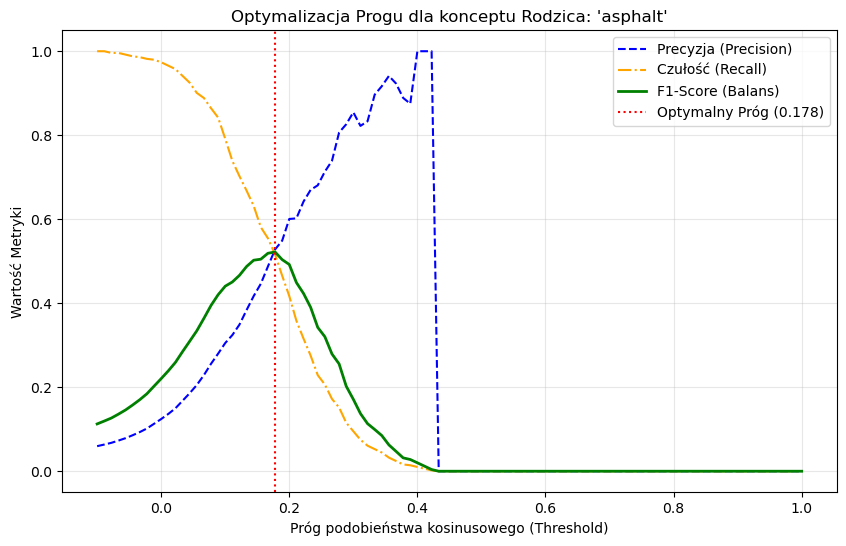

In [ ]:
sample_parent = 'asphalt'

if sample_parent in optimal_thresholds_dict:
    # Ponownie odpalamy funkcję, tylko żeby wyciągnąć historię do wykresu
    y_p = df_train[sample_parent].values
    idx_pos = np.where(y_p == 1.0)[0]
    idx_neg = np.where(y_p == 0.0)[0]
    cav_p = calculate_centroid_cav(X_train_clip, idx_pos, idx_neg)
    
    best_t, best_f, history = find_optimal_threshold(X_train_clip, y_p, cav_p)
    
    t_vals = [h[0] for h in history]
    f1_vals = [h[1] for h in history]
    p_vals = [h[2] for h in history]
    r_vals = [h[3] for h in history]
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_vals, p_vals, label='Precyzja (Precision)', linestyle='--', color='blue')
    plt.plot(t_vals, r_vals, label='Czułość (Recall)', linestyle='-.', color='orange')
    plt.plot(t_vals, f1_vals, label='F1-Score (Balans)', linewidth=2, color='green')
    
    plt.axvline(x=best_t, color='red', linestyle=':', label=f'Optymalny Próg ({best_t:.3f})')
    
    plt.title(f"Optymalizacja Progu dla konceptu Rodzica: '{sample_parent}'")
    plt.xlabel("Próg podobieństwa kosinusowego (Threshold)")
    plt.ylabel("Wartość Metryki")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
PARENTS_THRESHOLDS = {
    "enclosed area": 0.0667,
    "aged/ worn": 0.2222,
    "working": 0.1556,
    "natural light": -0.0444,
    "rock/stone": 0.3333,
    "cold": 0.3000,
    "asphalt": 0.1778,
    "open area": 0.0000
}



def get_matching_parent(X_obs, parent_cavs_dict, thresholds_dict):
    """
    Sprawdza do jakiego środowiska (rodzica) należy dana obserwacja.
    Zwraca pierwszy dopasowany kontekst: (nazwa_rodzica, wektor_rodzica) 
    lub (None, False), jeśli obserwacja nie należy do żadnego.
    """
    X_obs_flat = np.asarray(X_obs).flatten()
    norm_obs = np.linalg.norm(X_obs_flat)

    if norm_obs == 0:
        return None, False

    # Przeszukujemy dostępnych rodziców
    for parent_name, parent_cav in parent_cavs_dict.items():
        if parent_name not in thresholds_dict:
            continue
            
        threshold = thresholds_dict[parent_name]
        
        cav_flat = np.asarray(parent_cav).flatten()
        norm_cav = np.linalg.norm(cav_flat)
        
        if norm_cav == 0:
            continue
            
        # Szybki kosinus w czystym NumPy
        sim = np.dot(X_obs_flat, cav_flat) / (norm_obs * norm_cav)
        
        # Jeśli podobieństwo przekracza twardy próg, przerywamy i zwracamy sukces
        if sim >= threshold:
            return parent_name, parent_cav
            
    # Zwracamy False, jeśli żaden rodzic nie został dopasowany
    return None, False

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm

model_name = "CLIP (ViT-B/32)"
X_train_eval = X_train_clip
X_test_eval = X_test_clip
pairs = hierarchies_to_test

print("\n" + "="*100)
print(f" EWALUACJA ZEWNĘTRZNA KASKADY: {model_name.upper()}")
print("="*100)

# --- 1. SŁOWNIKI NA WEKTORY (FAZA TRENINGU) ---
parent_cavs = {}
child_cavs_std = {}
child_cavs_filt = {}
valid_pairs = []

# Wyliczamy wszystkie wektory raz, przed ewaluacją
for child, parent in pairs:
    y_train_c, y_train_p = df_train[child].values, df_train[parent].values
    
    idx_c_pos, idx_c_neg = np.where(y_train_c == 1.0)[0], np.where(y_train_c == 0.0)[0]
    idx_p_pos, idx_p_neg = np.where(y_train_p == 1.0)[0], np.where(y_train_p == 0.0)[0]
    
    if len(idx_c_pos) < 2 or len(idx_p_pos) < 2: 
        continue
        
    if parent not in parent_cavs:
        parent_cavs[parent] = calculate_centroid_cav(X_train_eval, idx_p_pos, idx_p_neg)
        
    child_cavs_std[(child, parent)] = calculate_centroid_cav(X_train_eval, idx_c_pos, idx_c_neg)
    child_cavs_filt[(child, parent)] = calculate_filtered_cav(X_train_eval, idx_c_pos, idx_c_neg, idx_p_pos)
    
    valid_pairs.append((child, parent))


# --- 2. INICJALIZACJA STRUKTUR TESTOWYCH ---
KARA_PUNKTOWA = -1.0
scores_std = {pair: np.full(len(X_test_eval), KARA_PUNKTOWA) for pair in valid_pairs}
scores_filt = {pair: np.full(len(X_test_eval), KARA_PUNKTOWA) for pair in valid_pairs}

out_of_domain_count = 0


# --- 3. GŁÓWNA PĘTLA INFERENCYJNA ---
for i in tqdm(range(len(X_test_eval)), desc="Przetwarzanie obserwacji"):
    obs = X_test_eval[i]
    
    # WYWOŁANIE FUNKCJI INFERENCYJNEJ
    matched_parent_name, matched_parent_cav = get_matching_parent(
        obs, parent_cavs, PARENTS_THRESHOLDS
    )
    
    if matched_parent_name is not None:
        # Obserwacja należy do rodzica! Szukamy dzieci powiązanych TYLKO z tym rodzicem
        children_to_check = [pair for pair in valid_pairs if pair[1] == matched_parent_name]
        
        norm_obs = np.linalg.norm(obs)
        if norm_obs == 0: 
            continue
        
        for pair in children_to_check:
            cav_std = child_cavs_std[pair]
            cav_filt = child_cavs_filt[pair]
            
            # Wyliczamy wynik podobieństwa do dziecka i nadpisujemy karę
            sim_std = np.dot(obs, cav_std) / (norm_obs * np.linalg.norm(cav_std))
            sim_filt = np.dot(obs, cav_filt) / (norm_obs * np.linalg.norm(cav_filt))
            
            scores_std[pair][i] = sim_std
            scores_filt[pair][i] = sim_filt
    else:
        # Obserwacja nie należy do żadnego rodzica (zostaje kara -1.0)
        out_of_domain_count += 1


# --- 4. EWALUACJA ROC AUC ---
print(f"\nOdrzucono {out_of_domain_count} z {len(X_test_eval)} obserwacji jako Out-of-Domain.\n")
print(f"{'SUBCONCEPT':<20} | {'PARENT':<18} | {'AUC STD':<10} | {'AUC FILT':<10} | {'DIFF'}")
print("-" * 100)

results = []
for pair in valid_pairs:
    child, parent = pair
    y_true_test = df_test[child].values
    
    if len(np.unique(y_true_test)) > 1:
        auc_std = roc_auc_score(y_true_test, scores_std[pair])
        auc_filt = roc_auc_score(y_true_test, scores_filt[pair])
        diff = auc_filt - auc_std
        results.append({'child': child, 'parent': parent, 'auc_std': auc_std, 'auc_filt': auc_filt, 'diff': diff})

# Sortowanie malejąco po różnicy
results.sort(key=lambda x: x['diff'], reverse=True)

for res in results:
    znak = "+++" if res['diff'] > 0 else "---" if res['diff'] < 0 else "==="
    print(f"{res['child']:<20} | {res['parent']:<18} | {res['auc_std']:<10.4f} | {res['auc_filt']:<10.4f} | {znak} {res['diff']:+.4f}")

# Zapisanie wyników do zmiennej dostępnej w Jupyterze
df_final = pd.DataFrame(results)


 EWALUACJA ZEWNĘTRZNA KASKADY: CLIP (VIT-B/32)


Przetwarzanie obserwacji:   0%|          | 0/2868 [00:00<?, ?it/s]

NameError: name 'get_matching_parent' is not defined

: 

: 

: 